In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
#uploading dataset
df=pd.read_csv("Delivery_Logistics.csv")

In [9]:
#understanding dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())
display(df.head())
df.info()

Number of rows: 25000
Number of columns: 15
Column names:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [10]:
#checking missing values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().sum() / len(df)
    ) * 100
})
display(missing)

,Missing Values,Percentage
delivery_id,0,0.0
delivery_partner,0,0.0
package_type,0,0.0
vehicle_type,0,0.0
delivery_mode,0,0.0
region,0,0.0
weather_condition,0,0.0
distance_km,0,0.0
package_weight_kg,0,0.0
delivery_time_hours,0,0.0


In [12]:
#checking duplicate records
duplicate_count = df.duplicated().sum()
print(
    "Number of duplicate records:",
    duplicate_count
)

Number of duplicate records: 0


In [73]:
#checking data types
print("Data types before preprocessing:")
display(df.dtypes)
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost"
]

# Preprocess 'delivery_time_hours' and 'expected_time_hours' before conversion
for col_to_clean in ["delivery_time_hours", "expected_time_hours"]:
    if col_to_clean in df.columns and df[col_to_clean].dtype == 'object':
        # Use string splitting to extract the last numerical part (e.g., '6' from '1970-01-01 00:00:00.000000006')
        # Add .str.strip() to remove any potential leading/trailing whitespace
        df[col_to_clean] = df[col_to_clean].astype(str).str.split('.').str[-1].str.strip()

# Temporarily convert only the numerical columns that are NOT the problematic time columns
# This allows us to inspect the string values of the time columns before full numeric conversion
for col in [c for c in numerical_columns if c not in ["delivery_time_hours", "expected_time_hours"]]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Display the dtypes of all numerical columns (including the problematic ones, still as object for now)
display(df[numerical_columns].dtypes)


Data types before preprocessing:


,0
delivery_id,float64
delivery_partner,object
package_type,object
vehicle_type,object
delivery_mode,object
region,object
weather_condition,object
distance_km,float64
package_weight_kg,float64
delivery_time_hours,float64


,0
distance_km,float64
package_weight_kg,float64
delivery_time_hours,float64
expected_time_hours,float64
delivery_rating,int64
delivery_cost,float64


In [22]:
#checking categorical columns
categorical_columns = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delayed",
    "delivery_status"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )
#checking unique values
for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print(df[col].value_counts())


delivery_partner
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

package_type
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

vehicle_type
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

delivery_mode
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

region
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

weather_condition
weather_condition
foggy 

In [71]:
#handling missing values
print("Missing values after initial cleaning:")
display(
    df.isnull().sum()
)
#median
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(
            df[col].median()
        )
#mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

print("Missing values after handling:")
display(
    df.isnull().sum()
)


Missing values after initial cleaning:


,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,25000


Missing values after handling:


,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,25000


In [31]:
#detecting outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]
    return outliers, lower_limit, upper_limit

outlier_summary = []
for col in numerical_columns:
    outliers, lower, upper = detect_outliers_iqr(
        df,
        col
    )
    outlier_summary.append({
        "Column": col,
        "Outliers": len(outliers),
        "Lower Limit": lower,
        "Upper Limit": upper
    })
outlier_summary = pd.DataFrame(
    outlier_summary
)
display(outlier_summary)

,Column,Outliers,Lower Limit,Upper Limit
0,distance_km,0,-147.600,448.400
1,package_weight_kg,0,-24.790,75.130
2,delivery_time_hours,0,NaN,NaN
3,expected_time_hours,0,NaN,NaN
4,delivery_rating,0,0.000,8.000
5,delivery_cost,0,-629.865,2358.575


Cannot visualize outliers for 'delivery_time_hours' as it contains only NaN values.
Please check the data cleaning steps for this column.


<Figure size 1000x500 with 0 Axes>

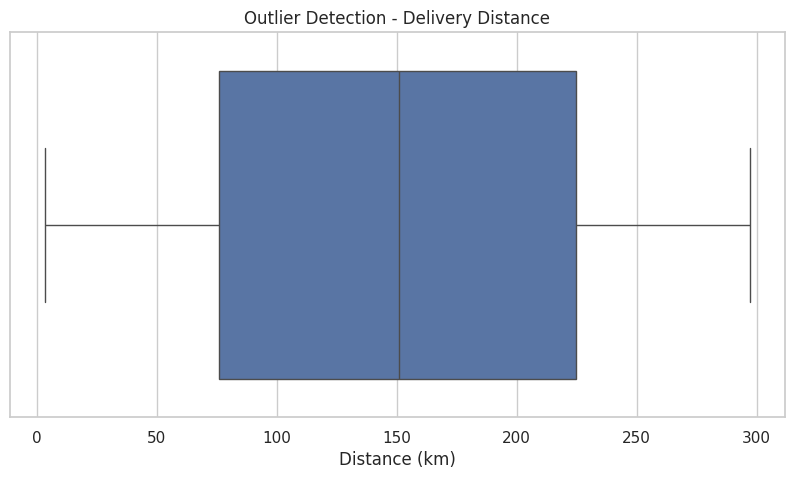

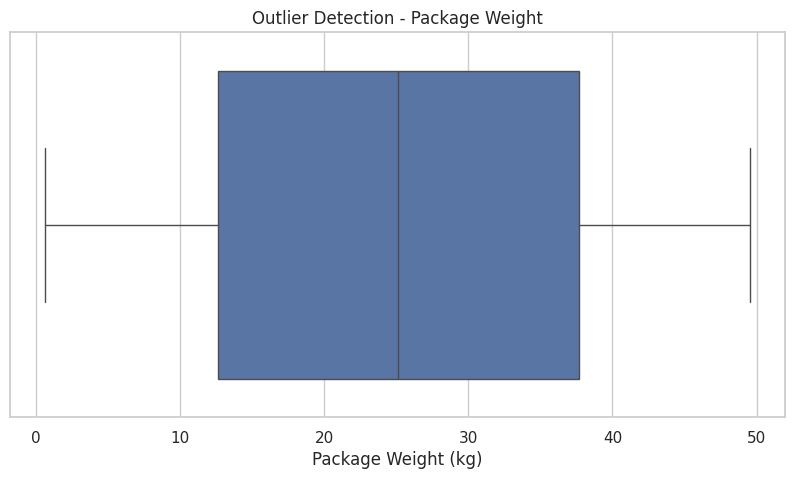

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))

if df["delivery_time_hours"].isnull().all():
    print("Cannot visualize outliers for 'delivery_time_hours' as it contains only NaN values.")
    print("Please check the data cleaning steps for this column.")
else:
    sns.boxplot(
        x=df["delivery_time_hours"]
    )
    plt.title(
        "Outlier Detection - Delivery Time"
    )
    plt.xlabel("Delivery Time (Hours)")
plt.show()
#distance
plt.figure(figsize=(10, 5))
sns.boxplot(
    x=df["distance_km"]
)
plt.title(
    "Outlier Detection - Delivery Distance"
)
plt.xlabel("Distance (km)")
plt.show()
#package weight
plt.figure(figsize=(10, 5))
sns.boxplot(
    x=df["package_weight_kg"]
)
plt.title(
    "Outlier Detection - Package Weight"
)
plt.xlabel("Package Weight (kg)")
plt.show()

In [44]:
#handling outliers
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    data[column] = data[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )
    return data
for col in numerical_columns:
    df = cap_outliers_iqr(
        df,
        col
    )
print("Outlier process completed.")

Outlier process completed.


In [51]:
#checking the data after outlier process
display(
    df[numerical_columns].describe()
)
plt.figure(figsize=(10, 5))

if df["delivery_time_hours"].isnull().all():
    print("Cannot visualize 'delivery_time_hours' after outlier treatment as it contains only NaN values.")
    print("Please re-check the data preprocessing steps for this column.")
else:
    sns.boxplot(
        x=df["delivery_time_hours"]
    )
    plt.title(
        "Delivery Time After Outlier Treatment"
    )
    plt.xlabel("Delivery Time (Hours)")
plt.show()

,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
count,25000.000000,25000.000000,0.0,0.0,25000.000000,25000.000000
mean,150.390436,25.145898,NaN,NaN,3.666000,864.944579
std,86.409745,14.368663,NaN,NaN,1.149964,435.712593
min,3.600000,0.670000,NaN,NaN,1.000000,95.667400
25%,75.900000,12.680000,NaN,NaN,3.000000,490.800000
50%,151.000000,25.145000,NaN,NaN,4.000000,867.535000
75%,224.900000,37.660000,NaN,NaN,5.000000,1237.910000
max,297.100000,49.520000,NaN,NaN,5.000000,1632.720600


Cannot visualize 'delivery_time_hours' after outlier treatment as it contains only NaN values.
Please re-check the data preprocessing steps for this column.


<Figure size 1000x500 with 0 Axes>

In [54]:
#normalizing numerical data
normalized_df = df.copy()
scaler = MinMaxScaler()
normalized_df[numerical_columns] = (
    scaler.fit_transform(
        normalized_df[numerical_columns]
    )
)
display(
    normalized_df[numerical_columns].head()
)

,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
0,0.999659,0.947595,NaN,NaN,0.50,1.000000
1,0.293015,0.956397,NaN,NaN,1.00,0.354251
2,0.919591,0.536745,NaN,NaN,0.75,0.879932
3,0.906644,0.246059,NaN,NaN,0.50,0.904915
4,0.862351,0.744115,NaN,NaN,0.75,0.845054


In [59]:
#comparing before and after of normalization
print("Original numerical data:")
display(
    df[numerical_columns].head()
)
print("Normalized numerical data:")
display(
    normalized_df[numerical_columns].head()
)


Original numerical data:


,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
0,297.0,46.96,NaN,NaN,3,1632.7206
1,89.6,47.39,NaN,NaN,5,640.1700
2,273.5,26.89,NaN,NaN,4,1448.1700
3,269.7,12.69,NaN,NaN,3,1486.5700
4,256.7,37.02,NaN,NaN,4,1394.5600


Normalized numerical data:


,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
0,0.999659,0.947595,NaN,NaN,0.50,1.000000
1,0.293015,0.956397,NaN,NaN,1.00,0.354251
2,0.919591,0.536745,NaN,NaN,0.75,0.879932
3,0.906644,0.246059,NaN,NaN,0.50,0.904915
4,0.862351,0.744115,NaN,NaN,0.75,0.845054


In [61]:
#final data quality check
print("Final Dataset Information")
print("----------------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(
    "Missing values:",
    df.isnull().sum().sum()
)
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Final Dataset Information
----------------------------
Rows: 25000
Columns: 15
Missing values: 50000
Duplicate rows: 0


In [74]:
#comparing original and cleaned dataset
raw_df = pd.read_csv("Delivery_Logistics.csv") # Load the original dataset into raw_df

comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Original": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df.isnull().sum().sum(),
        raw_df.duplicated().sum()
    ],

    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})
display(comparison)

,Metric,Original,After Cleaning
0,Rows,25000,25000
1,Columns,15,15
2,Missing Values,0,50000
3,Duplicate Rows,0,0


In [65]:
print("Unique values in original 'delivery_time_hours' (first 10 if many):")
display(raw_df['delivery_time_hours'].value_counts().head(10))

print("\nUnique values in original 'expected_time_hours' (first 10 if many):")
display(raw_df['expected_time_hours'].value_counts().head(10))

print("\nSample of problematic 'delivery_time_hours' entries from original raw_df (if any):")
display(raw_df[raw_df['delivery_time_hours'].astype(str).str.contains('[^0-9.]', regex=True)].head())

Unique values in original 'delivery_time_hours' (first 10 if many):


,count
delivery_time_hours,
1970-01-01 00:00:00.000000006,3118
1970-01-01 00:00:00.000000005,3011
1970-01-01 00:00:00.000000007,2921
1970-01-01 00:00:00.000000004,2571
1970-01-01 00:00:00.000000008,2386
1970-01-01 00:00:00.000000003,2352
1970-01-01 00:00:00.000000009,1875
1970-01-01 00:00:00.000000002,1668
1970-01-01 00:00:00.000000010,1371



Unique values in original 'expected_time_hours' (first 10 if many):


,count
expected_time_hours,
1970-01-01 00:00:00.000000016,6302
1970-01-01 00:00:00.000000008,6287
1970-01-01 00:00:00.000000024,6186
1970-01-01 00:00:00.000000005,1080
1970-01-01 00:00:00.000000007,1051
1970-01-01 00:00:00.000000004,1037
1970-01-01 00:00:00.000000003,1029
1970-01-01 00:00:00.000000002,1015
1970-01-01 00:00:00.000000006,1013



Sample of problematic 'delivery_time_hours' entries from original raw_df (if any):


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
